<a href="https://colab.research.google.com/github/ddoro1701/Assignment_01_Advanced_ML/blob/main/ML_police_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
import json
import zipfile
import joblib
import numpy as np
import pandas as pd

In [2]:
ZIP_PATH = "/content/Police_Data_ZIP.zip"
OUT_DIR = "/content/police_data"

os.makedirs(OUT_DIR, exist_ok=True)

csv_probe = glob.glob(os.path.join(OUT_DIR, "**", "*.csv"), recursive=True)
if len(csv_probe) == 0:
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(OUT_DIR)

print("OUT_DIR:", OUT_DIR)
print("CSV count:", len(glob.glob(os.path.join(OUT_DIR, '**', '*.csv'), recursive=True)))

OUT_DIR: /content/police_data
CSV count: 5


In [3]:
paths = sorted(glob.glob(os.path.join(OUT_DIR, "**", "*-north-wales-street.csv"), recursive=True))
print("Files found:", len(paths))
print(paths[:10])

df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
print("Loaded shape:", df.shape)
df.head()

Files found: 5
['/content/police_data/2025-09/2025-09-north-wales-street.csv', '/content/police_data/2025-10/2025-10-north-wales-street.csv', '/content/police_data/2025-11/2025-11-north-wales-street.csv', '/content/police_data/2025-12/2025-12-north-wales-street.csv', '/content/police_data/2026-01/2026-01-north-wales-street.csv']
Loaded shape: (24996, 12)


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,NaN,2025-09,North Wales Police,North Wales Police,-2.896347,53.094172,On or near Park/Open Space,E01018339,Cheshire West and Chester 047A,Anti-social behaviour,NaN,NaN
1,0a6a15cec3cbdf04d4534c4123dc63bd25755b094063e6...,2025-09,North Wales Police,North Wales Police,-2.897508,53.094002,On or near Park/Open Space,E01018339,Cheshire West and Chester 047A,Violence and sexual offences,Under investigation,NaN
2,NaN,2025-09,North Wales Police,North Wales Police,-3.814668,53.318280,On or near Clarence Drive,W01000132,Conwy 001A,Anti-social behaviour,NaN,NaN
3,NaN,2025-09,North Wales Police,North Wales Police,-3.811966,53.320074,On or near Curzon Road,W01000132,Conwy 001A,Anti-social behaviour,NaN,NaN
4,NaN,2025-09,North Wales Police,North Wales Police,-3.811356,53.320542,On or near Supermarket,W01000132,Conwy 001A,Anti-social behaviour,NaN,NaN


In [4]:
df["Month"] = pd.to_datetime(df["Month"], format="%Y-%m", errors="coerce")

for c in ["Latitude", "Longitude"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["Crime ID", "Last outcome category", "Context"]:
    if c in df.columns:
        df = df.drop(columns=[c])

for c in ["Reported by", "Falls within"]:
    if c in df.columns and df[c].nunique(dropna=False) <= 1:
        df = df.drop(columns=[c])

if "Location" in df.columns:
    df = df.drop(columns=["Location"])

df = df.dropna(subset=["Crime type", "Month"]).copy()

df["month_num"] = df["Month"].dt.month.astype(int)
df["year"] = df["Month"].dt.year.astype(int)

print("Shape:", df.shape)
print("Months:", sorted(df["Month"].dt.strftime("%Y-%m").unique()))
print(df["Crime type"].value_counts().head(15))

Shape: (24996, 8)
Months: ['2025-09', '2025-10', '2025-11', '2025-12', '2026-01']
Crime type
Violence and sexual offences    10317
Anti-social behaviour            4618
Shoplifting                      2228
Criminal damage and arson        1979
Public order                     1661
Other theft                      1415
Drugs                             710
Burglary                          669
Other crime                       497
Vehicle crime                     465
Possession of weapons             198
Bicycle theft                     123
Robbery                            80
Theft from the person              36
Name: count, dtype: int64


In [5]:
train_mask = (df["Month"] >= "2025-09-01") & (df["Month"] <= "2025-11-01")
val_mask   = (df["Month"] == "2025-12-01")
test_mask  = (df["Month"] == "2026-01-01")

print("Rows train:", int(train_mask.sum()))
print("Rows val:", int(val_mask.sum()))
print("Rows test:", int(test_mask.sum()))

Rows train: 15465
Rows val: 4622
Rows test: 4909


In [6]:
top_k = 8

y_train_raw = df.loc[train_mask, "Crime type"].astype(str)
top_labels = y_train_raw.value_counts().head(top_k).index.tolist()

def map_target(s):
    s = s.astype(str)
    return s.where(s.isin(top_labels), other="Other")

df.loc[train_mask, "target"] = map_target(df.loc[train_mask, "Crime type"])
df.loc[val_mask, "target"]   = map_target(df.loc[val_mask, "Crime type"])
df.loc[test_mask, "target"]  = map_target(df.loc[test_mask, "Crime type"])

print(df.loc[train_mask, "target"].value_counts())

target
Violence and sexual offences    6426
Anti-social behaviour           2884
Shoplifting                     1292
Criminal damage and arson       1241
Public order                    1065
Other theft                      865
Other                            830
Drugs                            435
Burglary                         427
Name: count, dtype: int64


In [7]:
drop_cols = ["Crime type", "target", "Month"]
X_train = df.loc[train_mask].drop(columns=drop_cols)
y_train = df.loc[train_mask, "target"]

X_val = df.loc[val_mask].drop(columns=drop_cols)
y_val = df.loc[val_mask, "target"]

X_test = df.loc[test_mask].drop(columns=drop_cols)
y_test = df.loc[test_mask, "target"]

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("Classes train:", y_train.nunique(), "val:", y_val.nunique(), "test:", y_test.nunique())

X_train: (15465, 6) X_val: (4622, 6) X_test: (4909, 6)
Classes train: 9 val: 9 test: 9


In [8]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

defaults = {}
for c in num_cols:
    defaults[c] = float(np.nanmedian(X_train[c].values))
for c in cat_cols:
    mode = X_train[c].mode(dropna=True)
    defaults[c] = str(mode.iloc[0]) if len(mode) else ""

print("Num cols:", len(num_cols), "Cat cols:", len(cat_cols))
print("Example defaults:", list(defaults.items())[:10])

Num cols: 4 Cat cols: 2
Example defaults: [('Longitude', -3.479908), ('Latitude', 53.217441), ('month_num', 10.0), ('year', 2025.0), ('LSOA code', 'W01000240'), ('LSOA name', 'Denbighshire 004E')]


In [9]:
from sklearn.metrics import accuracy_score, f1_score

major = y_train.value_counts().idxmax()
pred_val_base = np.full(len(y_val), major, dtype=object)
pred_test_base = np.full(len(y_test), major, dtype=object)

print("Baseline label:", major)
print("Val accuracy:", accuracy_score(y_val, pred_val_base))
print("Val macro F1:", f1_score(y_val, pred_val_base, average="macro"))
print("Test accuracy:", accuracy_score(y_test, pred_test_base))
print("Test macro F1:", f1_score(y_test, pred_test_base, average="macro"))

Baseline label: Violence and sexual offences
Val accuracy: 0.40761575075724793
Val macro F1: 0.06435085562045291
Test accuracy: 0.4088409044611937
Test macro F1: 0.06448814343551185


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

In [11]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def fit_eval(name, model):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, pred)
    f1m = f1_score(y_val, pred, average="macro")
    return name, acc, f1m, pipe

candidates = []

candidates.append(("LogReg",
                   LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)))

candidates.append(("SGD_logloss",
                   SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=3000,
                                 class_weight="balanced", random_state=42)))

svc = LinearSVC(class_weight="balanced", random_state=42)
candidates.append(("LinearSVC_calibrated",
                   CalibratedClassifierCV(svc, method="sigmoid", cv=3)))

candidates.append(("RandomForest",
                   RandomForestClassifier(n_estimators=500, max_depth=25,
                                          min_samples_leaf=2, n_jobs=-1,
                                          class_weight="balanced_subsample",
                                          random_state=42)))

rows = []
pipes = {}

for name, model in candidates:
    n, acc, f1m, pipe = fit_eval(name, model)
    rows.append((n, acc, f1m))
    pipes[n] = pipe
    print(n, "Val accuracy:", acc, "Val macro F1:", f1m)

results_df = pd.DataFrame(rows, columns=["model", "val_accuracy", "val_macro_f1"]).sort_values("val_macro_f1", ascending=False)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg Val accuracy: 0.151665945478148 Val macro F1: 0.12482318235755242
SGD_logloss Val accuracy: 0.40761575075724793 Val macro F1: 0.06435085562045291
LinearSVC_calibrated Val accuracy: 0.4123755949805279 Val macro F1: 0.0896073650164055
RandomForest Val accuracy: 0.27715274772825615 Val macro F1: 0.18593357730896684


,model,val_accuracy,val_macro_f1
3,RandomForest,0.277153,0.185934
0,LogReg,0.151666,0.124823
2,LinearSVC_calibrated,0.412376,0.089607
1,SGD_logloss,0.407616,0.064351


In [12]:
from sklearn.metrics import classification_report

best_name = results_df.iloc[0]["model"]
best_pipe = pipes[best_name]

pred_test = best_pipe.predict(X_test)

print("Best model:", best_name)
print("Test accuracy:", accuracy_score(y_test, pred_test))
print("Test macro F1:", f1_score(y_test, pred_test, average="macro"))
print(classification_report(y_test, pred_test))

Best model: RandomForest
Test accuracy: 0.2456712161336321
Test macro F1: 0.16663998004304734
                              precision    recall  f1-score   support

       Anti-social behaviour       0.24      0.32      0.27       919
                    Burglary       0.02      0.09      0.04       105
   Criminal damage and arson       0.08      0.09      0.09       372
                       Drugs       0.05      0.09      0.06       120
                       Other       0.05      0.04      0.05       294
                 Other theft       0.07      0.12      0.09       271
                Public order       0.07      0.05      0.05       316
                 Shoplifting       0.52      0.50      0.51       505
Violence and sexual offences       0.47      0.27      0.34      2007

                    accuracy                           0.25      4909
                   macro avg       0.17      0.17      0.17      4909
                weighted avg       0.31      0.25      0.26     

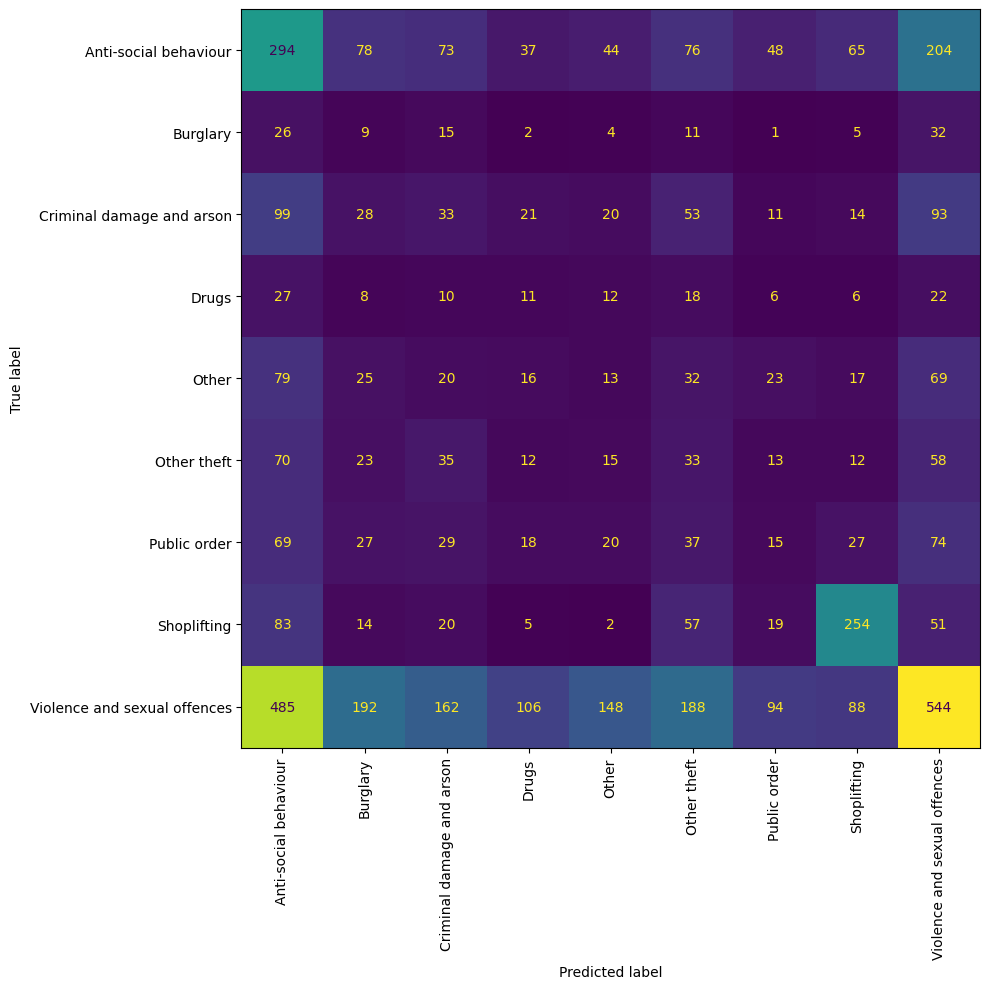

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

os.makedirs("artifacts/figures", exist_ok=True)

labels = sorted(pd.unique(y_test))
cm = confusion_matrix(y_test, pred_test, labels=labels)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.tight_layout()
plt.savefig("artifacts/figures/confusion_matrix_test.png", dpi=200)
plt.show()

In [14]:
trainval_mask = train_mask | val_mask

X_trainval = df.loc[trainval_mask].drop(columns=drop_cols)
y_trainval = df.loc[trainval_mask, "target"]

final_pipe = Pipeline([("prep", preprocess), ("model", best_pipe.named_steps["model"])])
final_pipe.fit(X_trainval, y_trainval)

joblib.dump(final_pipe, "artifacts/model.joblib")

meta = {
    "data_months": sorted(df["Month"].dt.strftime("%Y-%m").unique().tolist()),
    "split": {
        "train": sorted(df.loc[train_mask, "Month"].dt.strftime("%Y-%m").unique().tolist()),
        "val": sorted(df.loc[val_mask, "Month"].dt.strftime("%Y-%m").unique().tolist()),
        "test": sorted(df.loc[test_mask, "Month"].dt.strftime("%Y-%m").unique().tolist()),
    },
    "target_top_k": int(top_k),
    "target_labels_train_top_k": top_labels,
    "target_labels_all": sorted(df["target"].dropna().unique().tolist()),
    "feature_columns": X_train.columns.tolist(),
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "defaults": defaults,
    "best_model": str(best_name),
}

with open("artifacts/meta.json", "w") as f:
    json.dump(meta, f, indent=2)

results_df.to_csv("artifacts/val_results.csv", index=False)

print("Saved artifacts:")
print(os.listdir("artifacts"))
print(os.listdir("artifacts/figures"))

Saved artifacts:
['val_results.csv', 'meta.json', 'figures', 'model.joblib']
['confusion_matrix_test.png']


In [15]:
row = pd.DataFrame([meta["defaults"]])
row = row.reindex(columns=meta["feature_columns"])
pred = final_pipe.predict(row)[0]

proba = None
if hasattr(final_pipe, "predict_proba"):
    proba = final_pipe.predict_proba(row)[0]
    top = pd.DataFrame({"label": final_pipe.classes_, "prob": proba}).sort_values("prob", ascending=False).head(5)
    print("Prediction:", pred)
    print(top)
else:
    print("Prediction:", pred)

Prediction: Violence and sexual offences
                          label      prob
8  Violence and sexual offences  0.169938
4                         Other  0.133638
0         Anti-social behaviour  0.121574
5                   Other theft  0.105734
1                      Burglary  0.104201


In [16]:
app_py = r'''
import json
import joblib
import numpy as np
import pandas as pd
import streamlit as st

st.set_page_config(page_title="Crime type prediction", layout="centered")

model = joblib.load("artifacts/model.joblib")
meta = json.load(open("artifacts/meta.json", "r"))

st.title("Crime type prediction")
st.write("Inputs match the training features. The model predicts one of the top categories plus Other.")

defaults = meta["defaults"].copy()
feature_columns = meta["feature_columns"]

st.subheader("Inputs")

year = st.selectbox("Year", sorted(list(set([int(x.split("-")[0]) for x in meta["data_months"]]))))
month_num = st.selectbox("Month", list(range(1, 13)))

defaults["year"] = int(year)
defaults["month_num"] = int(month_num)

cat_cols = meta["cat_cols"]
num_cols = meta["num_cols"]

user_values = {}

for c in cat_cols:
    v = st.text_input(c, value=str(defaults.get(c, "")))
    user_values[c] = v

for c in num_cols:
    if c in ["year", "month_num"]:
        continue
    v0 = float(defaults.get(c, 0.0))
    v = st.number_input(c, value=v0)
    user_values[c] = float(v)

row = defaults.copy()
row.update(user_values)

X = pd.DataFrame([row]).reindex(columns=feature_columns)

if st.button("Predict"):
    pred = model.predict(X)[0]
    st.write("Prediction:", pred)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[0]
        out = pd.DataFrame({"label": model.classes_, "prob": proba}).sort_values("prob", ascending=False).head(5)
        st.dataframe(out, use_container_width=True)
'''
with open("app.py", "w") as f:
    f.write(app_py)

print("Wrote app.py")

Wrote app.py


In [17]:
req = """pandas
numpy
scikit-learn
joblib
matplotlib
streamlit
"""
with open("requirements.txt", "w") as f:
    f.write(req)

gi = """data/
police_data/
*.zip
__pycache__/
.ipynb_checkpoints/
.DS_Store
"""
with open(".gitignore", "w") as f:
    f.write(gi)

print("Wrote requirements.txt and .gitignore")

Wrote requirements.txt and .gitignore
